# PROBLEM STATEMENT

You have been hired as a consultant to a start-up that is running a targetted marketing ads on facebook. The company wants to anaylze customer behaviour by predicting which customer clicks on the advertisement. Customer data is as follows:

Inputs:
- Name
- e-mail
- Country
- Time on Facebook
- Estimated Salary (derived from other parameters)

Outputs:
- Click (1: customer clicked on Ad, 0: Customer did not click on the Ad)



# STEP #0: LIBRARIES IMPORT


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# STEP #1: IMPORT DATASET

In [6]:
# Read the data using pandas dataframe

dataset = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/master/Data%20Sets/Facebook_Ads_2.csv', encoding='ISO-8859-1')

In [7]:
# Show the data head!

dataset.head()

,Names,emails,Country,Time Spent on Site,Salary,Clicked
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,25.649648,55330.06006,0
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,32.456107,79049.07674,1
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,20.945978,41098.60826,0
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,54.039325,37143.35536,1
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,34.249729,37355.11276,0


In [8]:
# Show the data tail!

dataset.tail()

,Names,emails,Country,Time Spent on Site,Salary,Clicked
494,Rigel,egestas.blandit.Nam@semvitaealiquam.com,Sao Tome and Principe,19.222746,44969.13495,0
495,Walter,ligula@Cumsociis.ca,Nepal,22.665662,41686.20425,0
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,35.320239,23989.80864,0
497,Pearl,penatibus.et@massanonante.com,Philippines,26.539170,31708.57054,0
498,Nell,Quisque.varius@arcuVivamussit.net,Botswana,32.386148,74331.35442,1


# STEP #2: EXPLORE/VISUALIZE DATASET

In [9]:
# Check for missing data

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Names               499 non-null    object 
 1   emails              499 non-null    object 
 2   Country             499 non-null    object 
 3   Time Spent on Site  499 non-null    float64
 4   Salary              499 non-null    float64
 5   Clicked             499 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 23.5+ KB


,count
Clicked,
1,250
0,249


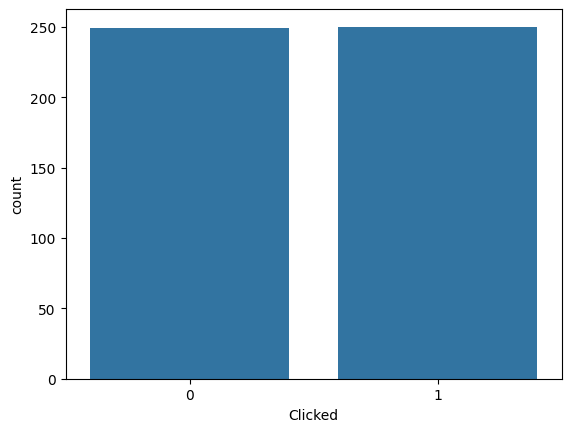

In [10]:
# Check click counts

sns.countplot(x = 'Clicked', data = dataset)
dataset['Clicked'].value_counts()

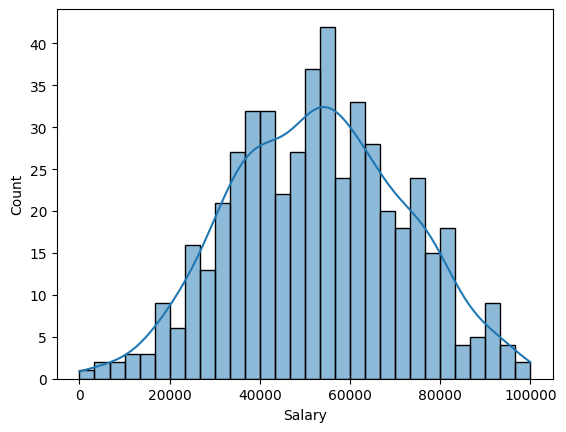

In [11]:
# Check Salary Distribution via Histogram

sns.histplot(dataset['Salary'], bins = 30, kde = True)
plt.show()

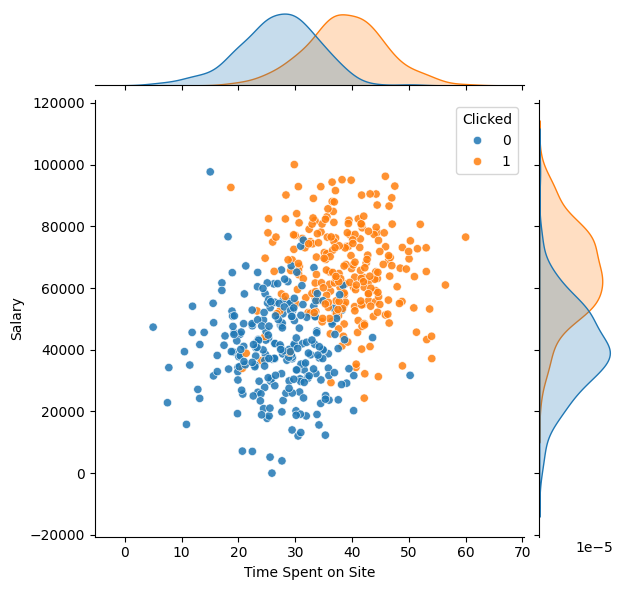

In [12]:
# Check JointPlot (Time Spent vs. Salary)

sns.jointplot(x = 'Time Spent on Site', y = 'Salary', hue = 'Clicked', data = dataset, alpha = 0.85, color = 'green')

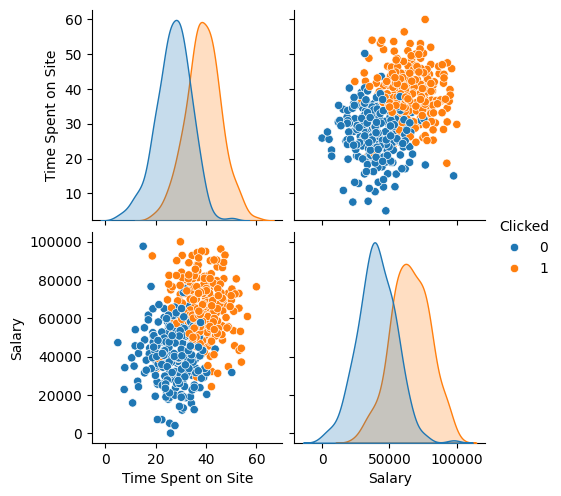

In [13]:
# Check A PairPlot (Clicked)

sns.pairplot(data = dataset, hue = 'Clicked')
plt.show()

# STEP #3: PREPARE THE DATA FOR TRAINING/ DATA CLEANING

In [14]:
dataset.head(3)

,Names,emails,Country,Time Spent on Site,Salary,Clicked
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,25.649648,55330.06006,0
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,32.456107,79049.07674,1
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,20.945978,41098.60826,0


In [15]:
#Let's drop the emails, country and names (we can make use of the country later!)

new_data = dataset.drop(['Names', 'emails', 'Country'], axis = 1)
new_data.head()

,Time Spent on Site,Salary,Clicked
0,25.649648,55330.06006,0
1,32.456107,79049.07674,1
2,20.945978,41098.60826,0
3,54.039325,37143.35536,1
4,34.249729,37355.11276,0


In [16]:
# Since we are going to normalize/scale the data, let us insert validation set for prediction testing (unseen data)

sample_data = np.array([[13.45, 50000, -1], [23.51, 75000, -1]]) # This is the data that we will predict

validation_data = pd.DataFrame(sample_data, index = [499, 500], columns = list(new_data.columns))
validation_data

,Time Spent on Site,Salary,Clicked
499,13.45,50000.0,-1.0
500,23.51,75000.0,-1.0


In [17]:
# Concatenate validation data to existing data

new_data = pd.concat([new_data, validation_data], axis = 0)
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, 0 to 500
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time Spent on Site  501 non-null    float64
 1   Salary              501 non-null    float64
 2   Clicked             501 non-null    float64
dtypes: float64(3)
memory usage: 15.7 KB


In [18]:
# This is the new data with new entries

new_data

,Time Spent on Site,Salary,Clicked
0,25.649648,55330.06006,0.0
1,32.456107,79049.07674,1.0
2,20.945978,41098.60826,0.0
3,54.039325,37143.35536,1.0
4,34.249729,37355.11276,0.0
...,...,...,...
496,35.320239,23989.80864,0.0
497,26.539170,31708.57054,0.0
498,32.386148,74331.35442,1.0
499,13.450000,50000.00000,-1.0


In [19]:
#Let's drop the target coloumn before we do train test split

X = new_data.drop('Clicked', axis = 1)
y = new_data['Clicked']

In [20]:
X

,Time Spent on Site,Salary
0,25.649648,55330.06006
1,32.456107,79049.07674
2,20.945978,41098.60826
3,54.039325,37143.35536
4,34.249729,37355.11276
...,...,...
496,35.320239,23989.80864
497,26.539170,31708.57054
498,32.386148,74331.35442
499,13.450000,50000.00000


In [21]:
# Feature Scaling/Normalization

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
scaled_X = sc.fit_transform(X)

scaled_X = pd.DataFrame(scaled_X, columns = list(new_data.columns[:2]))
scaled_X

,Time Spent on Site,Salary
0,-0.790258,0.126315
1,-0.044529,1.377425
2,-1.305602,-0.624353
3,2.320172,-0.832981
4,0.151984,-0.821811
...,...,...
496,0.269271,-1.526793
497,-0.692800,-1.119650
498,-0.052194,1.128579
499,-2.126876,-0.154830


In [22]:
# Remove index 499 & 500 (validation data) - variables

X = scaled_X.iloc[:499,:]
X

,Time Spent on Site,Salary
0,-0.790258,0.126315
1,-0.044529,1.377425
2,-1.305602,-0.624353
3,2.320172,-0.832981
4,0.151984,-0.821811
...,...,...
494,-1.494402,-0.420194
495,-1.117190,-0.593359
496,0.269271,-1.526793
497,-0.692800,-1.119650


In [23]:
# Remove index 499 & 500 (validation data) - class

y = y.iloc[:499]
y

,Clicked
0,0.0
1,1.0
2,0.0
3,1.0
4,0.0
...,...
494,0.0
495,0.0
496,0.0
497,0.0


# STEP#4: MODEL TRAINING

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 101)

In [26]:
# X_train

X_train

,Time Spent on Site,Salary
187,1.548404,1.914312
55,-0.594977,-0.639340
457,-0.821247,-0.830414
57,1.556663,1.465025
308,1.207145,1.288945
...,...,...
63,-0.147269,-0.931412
326,1.100091,1.343276
337,0.483817,-0.146457
11,0.182789,-1.198066


In [27]:
# y_train

y_train

,Clicked
187,1.0
55,0.0
457,0.0
57,1.0
308,1.0
...,...
63,0.0
326,1.0
337,0.0
11,0.0


In [28]:
# X_test

X_test

,Time Spent on Site,Salary
246,-1.418103,-1.199157
491,0.472287,0.570465
330,1.192960,-0.113793
453,-0.406024,-0.714251
155,-0.233580,-0.312400
...,...,...
98,-2.190857,-1.360192
183,-1.008913,-1.219894
72,-0.706926,0.129409
367,1.292712,1.186333


In [29]:
# y_test

y_test

,Clicked
246,0.0
491,1.0
330,1.0
453,0.0
155,0.0
...,...
98,0.0
183,0.0
72,0.0
367,1.0


In [30]:
# Fitting Logistic Regression to the Training set

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state = 101)
model.fit(X_train, y_train)

LogisticRegression(random_state=101)

# STEP#5: MODEL TESTING

In [31]:
prediction = model.predict(X_test)
prediction

array([0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
       0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.])

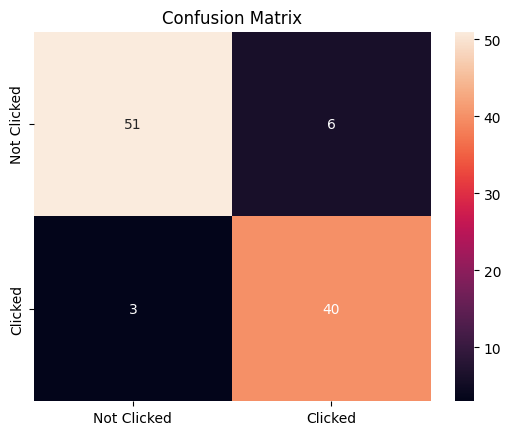

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix

cm = confusion_matrix(y_test, prediction)
sns.heatmap(cm, annot = True, fmt = "d", xticklabels = ['Not Clicked', 'Clicked'], yticklabels = ['Not Clicked', 'Clicked']).set(title = 'Confusion Matrix')
plt.show()

In [33]:
# Classification Report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

         0.0       0.94      0.89      0.92        57
         1.0       0.87      0.93      0.90        43

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



In [34]:
 # Sample Prediction (Input the Scaled Version)

y_prediction = model.predict(scaled_X.iloc[499:,:])
y_prediction

array([0., 1.])

In [35]:
# Sample Prediction (Input the Scaled Version), DataFrame

y_prediction = model.predict(scaled_X.iloc[499:,:])
y_prediction = pd.DataFrame(y_prediction, index = [499, 500], columns = ['Class'])
y_prediction

,Class
499,0.0
500,1.0


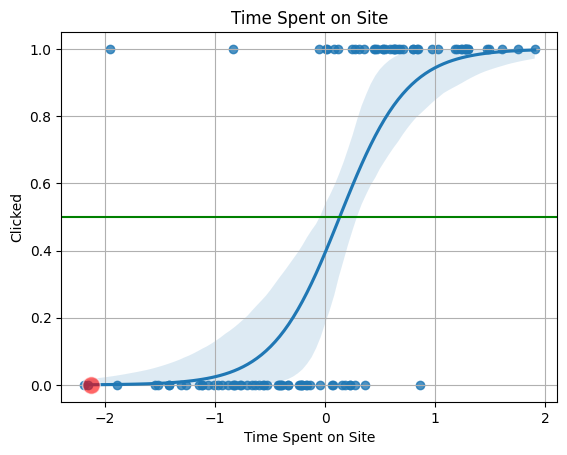

In [36]:
# Plot Logistic Regression Curve (Time Spent on Site) - Updated Code

sns.regplot(x = X_test.loc[:, 'Time Spent on Site'], y = prediction, data = scaled_X, logistic = True).set(ylabel = 'Clicked')
sns.scatterplot(x = [scaled_X.loc[499, 'Time Spent on Site']], y = [y_prediction.loc[499, 'Class']], color = 'red', zorder = 5, alpha = 0.6, s = 160)
plt.title('Time Spent on Site')
plt.axhline(0.5, color = 'green')
plt.grid()
plt.show()




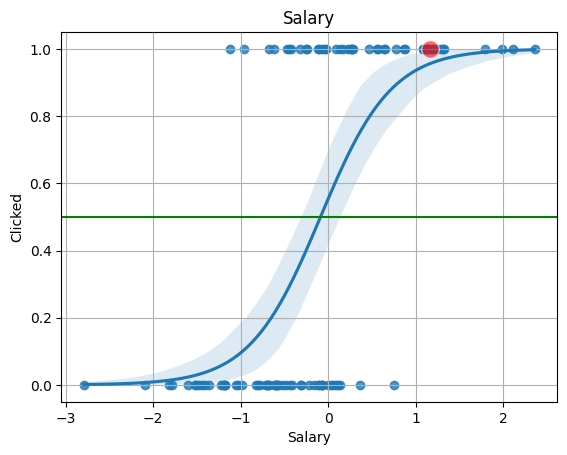

In [37]:
# Plot Logistic Regression Curve (Salary) - Updated Code

sns.regplot(x = X_test.loc[:, 'Salary'], y = prediction, data = scaled_X, logistic = True).set(ylabel = 'Clicked')
sns.scatterplot(x = [scaled_X.loc[500, 'Salary']], y = [y_prediction.loc[500, 'Class']], color = 'red', zorder = 5, alpha = 0.6, s = 160)
plt.title('Salary')
plt.axhline(0.5, color = 'green')
plt.grid()
plt.show()


In [47]:
#feature importance

coef = model.coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coef,
    "Abs_Importance": abs(coef)
}).sort_values(by="Abs_Importance", ascending=False)

# coef
feature_importance

# Positive coefficient → increases probability of class 1.
# Negative coefficient → decreases probability of class 1.

# As Time Spent on Site increases, the probability of belonging to class 1 increases.
# As Salary increases, the probability of belonging to class 1 also increases.

# If you exponentiate the coefficients:
# exp(2.237224) ≈ 9.37
# exp(2.151602) ≈ 8.60

# This means:
# A 1-unit increase in Time Spent on Site multiplies the odds of class 1 by about 9.37
# A 1-unit increase in Salary multiplies the odds of class 1 by about 8.60



,Feature,Coefficient,Abs_Importance
0,Time Spent on Site,2.237224,2.237224
1,Salary,2.151602,2.151602
